In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv(
    "../data/processed/cleaned_retail.csv"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalPrice,PurchaseHour,DayOfWeek,Year,Month,Day,Weekday,Hour,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,2009,12,1,Tuesday,7,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,2009,12,1,Tuesday,7,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,2009,12,1,Tuesday,7,4
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,2009,12,1,Tuesday,7,4
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,2009,12,1,Tuesday,7,4


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"]
      .sum()
      .reset_index()
)

daily_sales.columns = [
    "Date",
    "TotalPrice"
]

daily_sales.head()

,Date,TotalPrice
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [5]:
daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

daily_sales = daily_sales.sort_values("Date")

In [6]:
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="W"
        )
    )["TotalPrice"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,InvoiceDate,TotalPrice
0,2009-12-06,232177.51
1,2009-12-13,207908.73
2,2009-12-20,207685.87
3,2009-12-27,35731.90
4,2010-01-03,0.00


In [8]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="M"
        )
    )["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,InvoiceDate,TotalPrice
0,2009-12-31,683504.010
1,2010-01-31,555802.672
2,2010-02-28,504558.956
3,2010-03-31,696978.471
4,2010-04-30,591982.002


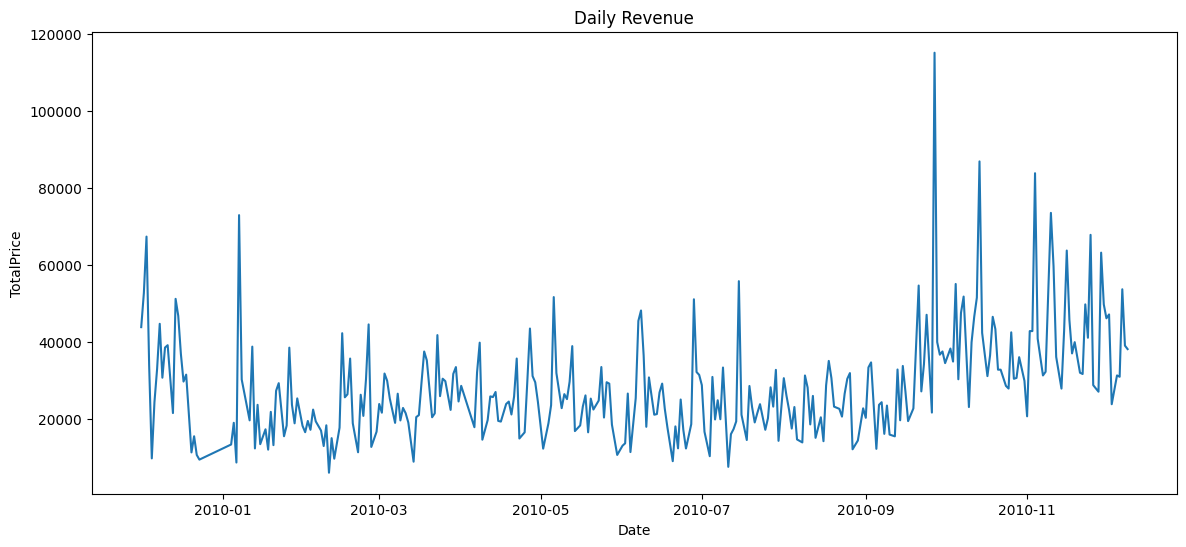

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["TotalPrice"]
)

plt.title("Daily Revenue")

plt.xlabel("Date")

plt.ylabel("TotalPrice")

plt.show()

In [10]:
date_range = pd.date_range(
    start=daily_sales["Date"].min(),
    end=daily_sales["Date"].max(),
    freq="D"
)

missing_dates = date_range.difference(
    daily_sales["Date"]
)

print("Missing Dates:", len(missing_dates))

Missing Dates: 67


In [11]:
daily_sales = (
    daily_sales
    .set_index("Date")
    .reindex(date_range)
    .fillna(0)
    .rename_axis("Date")
    .reset_index()
)

In [12]:
result = adfuller(
    daily_sales["TotalPrice"]
)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -2.5649768902848673
p-value : 0.10045400925889875
Critical Values:
1% : -3.448645946352023
5% : -2.869602139060357
10% : -2.5710650077160495


In [13]:
decomposition = seasonal_decompose(
    daily_sales["TotalPrice"],
    model="additive",
    period=30
)

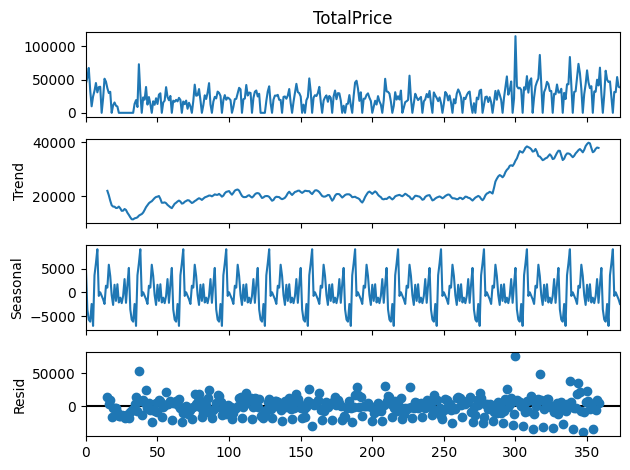

In [14]:
decomposition.plot()

plt.show()

In [15]:
daily_sales["Rolling_7"] = (
    daily_sales["TotalPrice"]
    .rolling(7)
    .mean()
)

daily_sales["Rolling_30"] = (
    daily_sales["TotalPrice"]
    .rolling(30)
    .mean()
)

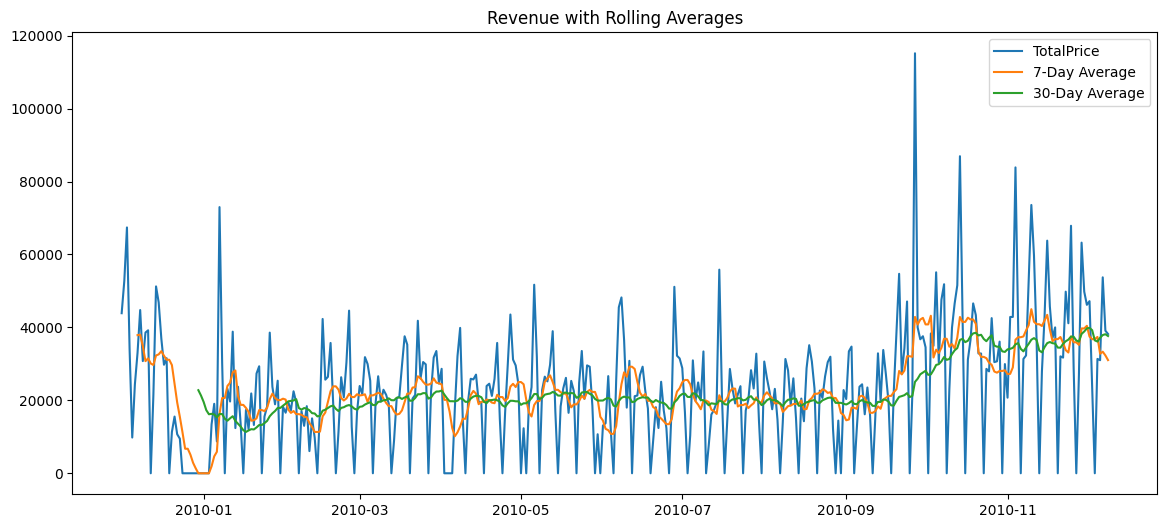

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["TotalPrice"],
    label="TotalPrice"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_7"],
    label="7-Day Average"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_30"],
    label="30-Day Average"
)

plt.legend()

plt.title("Revenue with Rolling Averages")

plt.show()

In [17]:
daily_sales.to_csv(
    "../data/processed/daily_sales.csv",
    index=False
)

weekly_sales.to_csv(
    "../data/processed/weekly_sales.csv",
    index=False
)

monthly_sales.to_csv(
    "../data/processed/monthly_sales.csv",
    index=False
)

In [18]:
print("Daily Sales Shape:", daily_sales.shape)

print("Weekly Sales Shape:", weekly_sales.shape)

print("Monthly Sales Shape:", monthly_sales.shape)

print("\nDate Range:")

print(daily_sales["Date"].min())

print(daily_sales["Date"].max())

Daily Sales Shape: (374, 4)
Weekly Sales Shape: (54, 2)
Monthly Sales Shape: (13, 2)

Date Range:
2009-12-01 00:00:00
2010-12-09 00:00:00
